# PTI-Clima Notebooks  <img src="https://www.r-project.org/logo/Rlogo.png" alt="Description" width="60" height="40">

***

> Este cuaderno o notebook muestra LO QUE MUESTRE EL NOTEBOOK utilizando los conjuntos de datos de la PTI-Clima que se incluyen en el [almacén de datos](https://pti.climate.ifca.es/data). Este trabajo está licenciado bajo una [Licencia Creative Commons Atribución 4.0 Internacional](http://creativecommons.org/licenses/by/4.0).
>
> ![Licencia de Creative Commons](https://i.creativecommons.org/l/by/4.0/88x31.png)


## Guía para la carga y comparación de datasets

**M. Fuente-González** (Instituto de Física de Cantabria, CSIC-Universidad de Cantabria, Santander, Spain).

**¡Bienvenidos al cuaderno "Guía para la carga y comparación de datasets" de la Plataforma Virtual de Cálculo de la PTI-Clima!**  
Esta guía tiene como objetivo ayudarte a entender y cargar diferentes datasets, de manera que puedas sacar el máximo provecho de los numerosos recursos disponibles en el [**Almacén de Datos de la PTI-Clima**](https://pti.climate.ifca.es/data). A través de esta plataforma, podrás realizar investigaciones y **análisis climáticos de relevancia**, ya que ofrece **acceso transparente a una amplia gama de materiales y datos** subyacentes a los **servicios climáticos desarrollados en la PTI-Clima**, fomentando su **reutilización** y posibilitando la **reproducibilidad** de los productos generados.

En concreto, esta guía pretende ayudarte a entender como cargar diferentes datasets para usar las diferentes variables en diferentes tipos de estudios, ya sea el cálculo de índices, análisis climáticos, etc. El objetivo principal es que comprendas de forma general la carga de datos y que puedas llevarlo a cabo en tus propias investigaciones. Se trata de un cuaderno que contiene conceptos básicos para poder entender y reproducir otros de manera más autodidácta. De esta manera vamos a **guiarte** a través de los pasos fundamentales para trabajar de manera efectiva con los datos este tipo de daatasets.

Tras la carga de datos, habrá bloques de visualizaciones, permitiendo familiarizarte con este tipo de análisis de resultados y permitiendote aprender diferentes tipos de representacionse. Para todo ello, se utilizará el **framework *climate4R***, un conjunto de librerías de R para la carga, post-procesamiento y análisis de datos climáticos. 


<img src="https://raw.githubusercontent.com/SantanderMetGroup/climate4R/refs/heads/devel/man/figures/climate4R_logo.svg" alt="Description" width="60" height="40">

***climate4R*** ofrece más funcionalidades de las que se ilustran en este notebook, como **funcionalidades de operaciones espaciales y temporales** o como **interpolación, subsetting o intersección espacial**. Además, brinda funcionalidades para la **corrección de sesgo y downscaling** o funciones específicas para el **cálculo del FWI**. Consulta [Iturbide et al., 2019](https://www.sciencedirect.com/science/article/pii/S1364815218303049?via%3Dihub) y el repositorio de [github de climate4R](https://github.com/SantanderMetGroup/climate4R) para más información.

### Contenido de este cuaderno
1) Carga de librerías
2) Selección de conjuntos de datos  
3) Carga de datos
   * 3.1. Dataset Chelsa
   * 3.2. Dataset PTI-V0
   * 3.3. Dataset PTI-V1
4) Análisis básico
   * 4.1. Medias climatológicas
   * 4.2. Comparación de las medias climátologicas de los tres datasets
   * 4.3. Series temporales 

Empezamos dando la memoria que queramos a la RAM (la suficiente para poder cargar varios datasets)

In [1]:
options(java.parameters = "-Xmx12g")

### 1. Carga de librerías

Cargamos las librerías necesarias. Las tres primeras corresponden a librerías del framework *climate4R* y las tres últimas se usarán para mostrar las visualizaciones.

In [2]:
library(loadeR)
library(transformeR)
library(visualizeR)
library(grid)
library(gridExtra)
library(ggplot2)

Loading required package: rJava

Loading required package: loadeR.java

Java version 22x amd64 by N/A detected

NetCDF Java Library v4.6.0-SNAPSHOT (23 Apr 2015) loaded and ready

Loading required package: climate4R.UDG

climate4R.UDG version 0.2.6 (2023-06-26) is loaded

Please use 'citation("climate4R.UDG")' to cite this package.

loadeR version 1.8.1 (2023-06-22) is loaded


Get the latest stable version (1.8.2) using <devtools::install_github(c('SantanderMetGroup/climate4R.UDG','SantanderMetGroup/loadeR'))>

Please use 'citation("loadeR")' to cite this package.




    _______   ____  ___________________  __  ________ 
   / ___/ /  / /  |/  / __  /_  __/ __/ / / / / __  / 
  / /  / /  / / /|_/ / /_/ / / / / __/ / /_/ / /_/_/  
 / /__/ /__/ / /  / / __  / / / / /__ /___  / / \ \ 
 \___/____/_/_/  /_/_/ /_/ /_/  \___/    /_/\/   \_\ 
 
      github.com/SantanderMetGroup/climate4R



transformeR version 2.2.2 (2023-10-26) is loaded


Get the latest stable version (2.2.3) using <devtools::install_github('SantanderMetGroup/transformeR')>

Please see 'citation("transformeR")' to cite this package.

visualizeR version 1.6.4 (2023-10-26) is loaded

Please see 'citation("visualizeR")' to cite this package.



### 2. Selección de conjuntos de datos  

Leemos el archivo donde se tiene el contenido de todos los datasets y vemos que pinta tiene para decidir que es lo que queremos cargar.

In [3]:
df <- read.csv("../data_inventory.csv")

In [4]:
head(df)

,dataset,type,access,source,provider,experiment,frequency,endpoint,dictionary
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,AEMET-5KM-regular_Iberia_day,observations,opendap,AEMET-5KM-regular,,,day,https://data.meteo.unican.es/thredds/dodsC/PTI-clima/observations/AEMET-5KM-regular_Iberia_day.ncml,../../Harmonization_dictionaries/AEMET-5KM-regular.dic
2,CHELSA-W5E5v1.0_Canarias_day,observations,opendap,CHELSA-W5E5v1.0,,,day,https://data.meteo.unican.es/thredds/dodsC/PTI-clima/observations/CHELSA-W5E5v1.0_Canarias_day.ncml,../../Harmonization_dictionaries/CHELSA-W5E5v1.0.dic
3,CHELSA-W5E5v1.0_Iberia_day,observations,opendap,CHELSA-W5E5v1.0,,,day,https://data.meteo.unican.es/thredds/dodsC/PTI-clima/observations/CHELSA-W5E5v1.0_Iberia_day.ncml,../../Harmonization_dictionaries/CHELSA-W5E5v1.0.dic
4,PTI-grid-v0_Canarias_day,observations,opendap,PTI-grid-v0,,,day,https://data.meteo.unican.es/thredds/dodsC/PTI-clima/observations/PTI-grid-v0_Canarias_day.ncml,../../Harmonization_dictionaries/PTI-grid-v0.dic
5,PTI-grid-v0_Iberia_day,observations,opendap,PTI-grid-v0,,,day,https://data.meteo.unican.es/thredds/dodsC/PTI-clima/observations/PTI-grid-v0_Iberia_day.ncml,../../Harmonization_dictionaries/PTI-grid-v0.dic
6,PTI-grid-v1_Canarias_day,observations,opendap,PTI-grid-v1,,,day,https://data.meteo.unican.es/thredds/dodsC/PTI-clima/observations/PTI-grid-v1_Canarias_day.ncml,../../Harmonization_dictionaries/PTI-grid-v1.dic


En este caso, vamos a cargar observaciones. Para ello, mostramos el subconjunto de los datasets que corresponden con *"observations"*. Hay datasets para la Península Ibérica (PI) y para las Islas Canarias. Cómo habitualmente se trabaja más con datasets de la PI, se van a escoger los de las Islas Canarias para ver las posibles diferencias entre datasets.

In [5]:
subset(df, type == "observations")

,dataset,type,access,source,provider,experiment,frequency,endpoint,dictionary
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,AEMET-5KM-regular_Iberia_day,observations,opendap,AEMET-5KM-regular,,,day,https://data.meteo.unican.es/thredds/dodsC/PTI-clima/observations/AEMET-5KM-regular_Iberia_day.ncml,../../Harmonization_dictionaries/AEMET-5KM-regular.dic
2,CHELSA-W5E5v1.0_Canarias_day,observations,opendap,CHELSA-W5E5v1.0,,,day,https://data.meteo.unican.es/thredds/dodsC/PTI-clima/observations/CHELSA-W5E5v1.0_Canarias_day.ncml,../../Harmonization_dictionaries/CHELSA-W5E5v1.0.dic
3,CHELSA-W5E5v1.0_Iberia_day,observations,opendap,CHELSA-W5E5v1.0,,,day,https://data.meteo.unican.es/thredds/dodsC/PTI-clima/observations/CHELSA-W5E5v1.0_Iberia_day.ncml,../../Harmonization_dictionaries/CHELSA-W5E5v1.0.dic
4,PTI-grid-v0_Canarias_day,observations,opendap,PTI-grid-v0,,,day,https://data.meteo.unican.es/thredds/dodsC/PTI-clima/observations/PTI-grid-v0_Canarias_day.ncml,../../Harmonization_dictionaries/PTI-grid-v0.dic
5,PTI-grid-v0_Iberia_day,observations,opendap,PTI-grid-v0,,,day,https://data.meteo.unican.es/thredds/dodsC/PTI-clima/observations/PTI-grid-v0_Iberia_day.ncml,../../Harmonization_dictionaries/PTI-grid-v0.dic
6,PTI-grid-v1_Canarias_day,observations,opendap,PTI-grid-v1,,,day,https://data.meteo.unican.es/thredds/dodsC/PTI-clima/observations/PTI-grid-v1_Canarias_day.ncml,../../Harmonization_dictionaries/PTI-grid-v1.dic
7,PTI-grid-v1_Iberia_day,observations,opendap,PTI-grid-v1,,,day,https://data.meteo.unican.es/thredds/dodsC/PTI-clima/observations/PTI-grid-v1_Iberia_day.ncml,../../Harmonization_dictionaries/PTI-grid-v1.dic


### 3. Carga de datos

#### Trabajamos con observaciones de Canarias
  

Tras ver los posibles datasets de observaciones correspondientes a las Islas Canarias, vamos cargando los datasets para cada uno de ellos.

#### 3.1. Dataset Chelsa

Primero llamamos al dataset concreto que queremos analizar, apuntando con el sufijo *endpoint*, a la url que queremos referirnos. A continuación, hacemos un inventario para saber que variables tiene el dataset y en que unidades están.

In [6]:
subset.chelsa <- subset(df, dataset == "CHELSA-W5E5v1.0_Canarias_day")
lon.chelsa <- as.character(subset.chelsa$endpoint)
obs.chelsa <- dataInventory(lon.chelsa)

[2025-05-12 12:04:18.401962] Doing inventory ...

[2025-05-12 12:04:18.628308] Opening dataset...

[2025-05-12 12:04:20.80121] The dataset was successfuly opened

[2025-05-12 12:04:21.787463] Retrieving info for 'orog' (5 vars remaining)

[2025-05-12 12:04:21.936008] Retrieving info for 'pr' (4 vars remaining)

[2025-05-12 12:04:22.067641] Retrieving info for 'rsds' (3 vars remaining)

[2025-05-12 12:04:22.136865] Retrieving info for 'tasmax' (2 vars remaining)

[2025-05-12 12:04:22.218559] Retrieving info for 'tasmin' (1 vars remaining)

[2025-05-12 12:04:22.287707] Retrieving info for 'tas' (0 vars remaining)

[2025-05-12 12:04:22.365582] Done.



In [7]:
str(obs.chelsa)

List of 6
 $ orog  :List of 7
  ..$ Description: chr "Surface Altitude"
  ..$ DataType   : chr "float"
  ..$ Shape      : int [1:3] 1 277 661
  ..$ Units      : chr "m"
  ..$ DataSizeMb : num 0.732
  ..$ Version    : logi NA
  ..$ Dimensions :List of 3
  .. ..$ time:List of 4
  .. .. ..$ Type      : chr "Time"
  .. .. ..$ TimeStep  : chr ".0 days"
  .. .. ..$ Units     : chr "days since 2000-01-01 00:00:00 GMT"
  .. .. ..$ Date_range: chr "2000-01-01T00:00:00Z - 2000-01-01T00:00:00Z"
  .. ..$ lat :List of 5
  .. .. ..$ Type       : chr "Lat"
  .. .. ..$ Units      : chr "degrees_north"
  .. .. ..$ Values     : num [1:277] 27.3 27.3 27.3 27.3 27.3 ...
  .. .. ..$ Shape      : int 277
  .. .. ..$ Coordinates: chr "lat"
  .. ..$ lon :List of 5
  .. .. ..$ Type       : chr "Lon"
  .. .. ..$ Units      : chr "degrees_east"
  .. .. ..$ Values     : num [1:661] -18.5 -18.5 -18.5 -18.5 -18.5 ...
  .. .. ..$ Shape      : int 661
  .. .. ..$ Coordinates: chr "lon"
 $ pr    :List of 7
  ..$ Descr

Vamos a cargar la temperatura máxima diaria, como se puede ver al hacer el inventario, hay que referirse a ella como *tasmax*. De todo el posible periodo que se tiene (1979-2016) vamos a cargar un año en específico (2005) y solo las estaciones de verano (Junio, Julio y Agosto).

In [8]:
tasmax.chelsa <- loadGridData(dataset = lon.chelsa,
                           var = "tasmax",
                           season = 6:8,
                           years = 2005)

[2025-05-12 12:04:22.675184] Opening dataset...

[2025-05-12 12:04:24.244731] The dataset was successfuly opened

[2025-05-12 12:04:24.2518] Defining geo-location parameters

[2025-05-12 12:04:24.357981] Defining time selection parameters

[2025-05-12 12:04:24.482712] Retrieving data subset ...

[2025-05-12 12:04:33.124822] Done



Volvemos a llamar a la funcion str para ver la pinta que tiene la temperatuar máxima, con esto podemos ver la resolución del dataset y las unidades (en caso de no habernos fijado antes)

In [9]:
str(tasmax.chelsa)

List of 4
 $ Variable:List of 2
  ..$ varName: chr "tasmax"
  ..$ level  : NULL
  ..- attr(*, "use_dictionary")= logi FALSE
  ..- attr(*, "description")= chr "Daily Maximum Near-Surface Air Temperature"
  ..- attr(*, "units")= chr "K"
  ..- attr(*, "longname")= chr "tasmax"
  ..- attr(*, "daily_agg_cellfun")= chr "none"
  ..- attr(*, "monthly_agg_cellfun")= chr "none"
  ..- attr(*, "verification_time")= chr "none"
 $ Data    : num [1:92, 1:277, 1:661] NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN ...
  ..- attr(*, "dimensions")= chr [1:3] "time" "lat" "lon"
 $ xyCoords:List of 2
  ..$ x: num [1:661] -18.5 -18.5 -18.5 -18.5 -18.5 ...
  ..$ y: num [1:277] 27.3 27.3 27.3 27.3 27.3 ...
  ..- attr(*, "projection")= chr "LatLonProjection"
  ..- attr(*, "resX")= num 0.00833
  ..- attr(*, "resY")= num 0.00833
 $ Dates   :List of 2
  ..$ start: chr [1:92] "2005-06-01 12:00:00 GMT" "2005-06-02 12:00:00 GMT" "2005-06-03 12:00:00 GMT" "2005-06-04 12:00:00 GMT" ...
  ..$ end  : chr [1:92] "2005-06-01 12:

Como los datos están en grados Kelvin en vez de grados Celsius, se hace uso de la función gridArithmetics, para hacer el cambio de unidades correspondiente.

In [10]:
tasmax.chelsa <- gridArithmetics(tasmax.chelsa, 273, operator ="-")

#### 3.2. Dataset PTI-V0

De la misma forma que se ha actuado para el dataset Chelsa, se actúa para los siguientes datasets PTI-V0 y PTI-V1. Como se verá a continuación, la única diferencia es que las unidades de la temperatura máxima son grados Celsius, por lo que no hará falta realizar ningún tipo de conversión.

In [12]:
subset.pti.v0 <- subset(df, dataset == "PTI-grid-v0_Canarias_day")
lon.pti.v0 <- as.character(subset.pti.v0$endpoint)
obs.pti.v0 <- dataInventory(lon.pti.v0)

[2025-05-12 12:04:48.981796] Doing inventory ...

[2025-05-12 12:04:49.144935] Opening dataset...

[2025-05-12 12:04:50.678647] The dataset was successfuly opened

[2025-05-12 12:04:52.07458] Retrieving info for 'pr' (4 vars remaining)

[2025-05-12 12:04:52.149646] Retrieving info for 'hr' (3 vars remaining)

[2025-05-12 12:04:52.236017] Retrieving info for 'tdew' (2 vars remaining)

[2025-05-12 12:04:52.319967] Retrieving info for 'tmax' (1 vars remaining)

[2025-05-12 12:04:52.388684] Retrieving info for 'tmin' (0 vars remaining)

[2025-05-12 12:04:52.530417] Done.



In [13]:
str(obs.pti.v0)

List of 5
 $ pr  :List of 7
  ..$ Description: chr "Precipitation"
  ..$ DataType   : chr "float"
  ..$ Shape      : int [1:3] 22645 71 189
  ..$ Units      : chr "mm"
  ..$ DataSizeMb : num 1215
  ..$ Version    : logi NA
  ..$ Dimensions :List of 3
  .. ..$ time:List of 4
  .. .. ..$ Type      : chr "Time"
  .. .. ..$ TimeStep  : chr "1.0 days"
  .. .. ..$ Units     : chr "days since 1961-01-01"
  .. .. ..$ Date_range: chr "1961-01-01T00:00:00Z - 2022-12-31T00:00:00Z"
  .. ..$ lat :List of 5
  .. .. ..$ Type       : chr "Lat"
  .. .. ..$ Units      : chr "degrees_north"
  .. .. ..$ Values     : num [1:71] 27.7 27.7 27.7 27.7 27.8 ...
  .. .. ..$ Shape      : int 71
  .. .. ..$ Coordinates: chr "lat"
  .. ..$ lon :List of 5
  .. .. ..$ Type       : chr "Lon"
  .. .. ..$ Units      : chr "degrees_east"
  .. .. ..$ Values     : num [1:189] -18.1 -18.1 -18.1 -18.1 -18 ...
  .. .. ..$ Shape      : int 189
  .. .. ..$ Coordinates: chr "lon"
 $ hr  :List of 7
  ..$ Description: chr "Relativ

In [14]:
tasmax.pti.v0 <- loadGridData(dataset = lon.pti.v0,
                           var = "tmax",
                           season = 6:8,
                           years = 2005)

[2025-05-12 12:05:05.85894] Opening dataset...

[2025-05-12 12:05:07.3049] The dataset was successfuly opened

[2025-05-12 12:05:07.311492] Defining geo-location parameters

[2025-05-12 12:05:07.40167] Defining time selection parameters

[2025-05-12 12:05:07.567949] Retrieving data subset ...

[2025-05-12 12:05:11.331616] Done



In [15]:
str(tasmax.pti.v0)

List of 4
 $ Variable:List of 2
  ..$ varName: chr "tmax"
  ..$ level  : NULL
  ..- attr(*, "use_dictionary")= logi FALSE
  ..- attr(*, "description")= chr "Maximum temperature"
  ..- attr(*, "units")= chr "grades celsius"
  ..- attr(*, "longname")= chr "tmax"
  ..- attr(*, "daily_agg_cellfun")= chr "none"
  ..- attr(*, "monthly_agg_cellfun")= chr "none"
  ..- attr(*, "verification_time")= chr "none"
 $ Data    : num [1:92, 1:71, 1:189] NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN ...
  ..- attr(*, "dimensions")= chr [1:3] "time" "lat" "lon"
 $ xyCoords:List of 2
  ..$ x: num [1:189] -18.1 -18.1 -18.1 -18.1 -18 ...
  ..$ y: num [1:71] 27.7 27.7 27.7 27.7 27.8 ...
  ..- attr(*, "projection")= chr "LatLonProjection"
  ..- attr(*, "resX")= num 0.025
  ..- attr(*, "resY")= num 0.025
 $ Dates   :List of 2
  ..$ start: chr [1:92] "2005-06-01 00:00:00 GMT" "2005-06-02 00:00:00 GMT" "2005-06-03 00:00:00 GMT" "2005-06-04 00:00:00 GMT" ...
  ..$ end  : chr [1:92] "2005-06-01 00:00:00 GMT" "2005-06-02

#### 3.3. Dataset PTI-V1

In [17]:
subset.pti.v1 <- subset(df, dataset == "PTI-grid-v1_Canarias_day")
lon.pti.v1 <- as.character(subset.pti.v1$endpoint)
obs.pti.v1 <- dataInventory(lon.pti.v1)

[2025-05-12 12:05:21.296882] Doing inventory ...

[2025-05-12 12:05:21.707862] Opening dataset...

Warning message in grepl("\\\\u[0-9A-Fa-f]", str):
“unable to translate '<!DOCTYPE HTML PUBLIC "-//W3C//DTD HTML 4.0 Transitional//EN"
"http://www.w3.org/TR/REC-html40/loose.dtd">
<html><head><title>OPeNDAP Dataset Query Form</title>
<link type="text/css" rel="stylesheet" media="screen" href="/thredds/tdsDap.css"/>
<base hr...' to a wide string”
Warning message in grepl("\\\\u[0-9A-Fa-f]", str):
“input string 1 is invalid”
Warning message in grepl("code = 404", htmlheader):
“unable to translate '<!DOCTYPE HTML PUBLIC "-//W3C//DTD HTML 4.0 Transitional//EN"
"http://www.w3.org/TR/REC-html40/loose.dtd">
<html><head><title>OPeNDAP Dataset Query Form</title>
<link type="text/css" rel="stylesheet" media="screen" href="/thredds/tdsDap.css"/>
<base hr...' to a wide string”
Warning message in grepl("code = 404", htmlheader):
“input string 1 is invalid”
Warning message in grepl("code = 503", htmlhe

In [18]:
str(obs.pti.v1)

List of 5
 $ pr  :List of 7
  ..$ Description: chr "Daily cumulative precipitation"
  ..$ DataType   : chr "float"
  ..$ Shape      : int [1:3] 22645 72 188
  ..$ Units      : chr "mm day-1"
  ..$ DataSizeMb : num 1226
  ..$ Version    : logi NA
  ..$ Dimensions :List of 3
  .. ..$ time     :List of 4
  .. .. ..$ Type      : chr "Time"
  .. .. ..$ TimeStep  : chr "1.0 days"
  .. .. ..$ Units     : chr "days since 1950-01-01T00:00:00"
  .. .. ..$ Date_range: chr "1961-01-01T00:00:00Z - 2022-12-31T00:00:00Z"
  .. ..$ latitude :List of 5
  .. .. ..$ Type       : chr "Lat"
  .. .. ..$ Units      : chr "degrees_north"
  .. .. ..$ Values     : num [1:72] 27.7 27.7 27.7 27.7 27.8 ...
  .. .. ..$ Shape      : int 72
  .. .. ..$ Coordinates: chr "latitude"
  .. ..$ longitude:List of 5
  .. .. ..$ Type       : chr "Lon"
  .. .. ..$ Units      : chr "degrees_east"
  .. .. ..$ Values     : num [1:188] -18.1 -18.1 -18.1 -18.1 -18 ...
  .. .. ..$ Shape      : int 188
  .. .. ..$ Coordinates: chr "lo

In [19]:
tasmax.pti.v1 <- loadGridData(dataset = lon.pti.v1,
                           var = "tmax",
                           season = 6:8,
                           years = 2005)

[2025-05-12 12:05:33.390189] Opening dataset...

Warning message in grepl("\\\\u[0-9A-Fa-f]", str):
“unable to translate '<!DOCTYPE HTML PUBLIC "-//W3C//DTD HTML 4.0 Transitional//EN"
"http://www.w3.org/TR/REC-html40/loose.dtd">
<html><head><title>OPeNDAP Dataset Query Form</title>
<link type="text/css" rel="stylesheet" media="screen" href="/thredds/tdsDap.css"/>
<base hr...' to a wide string”
Warning message in grepl("\\\\u[0-9A-Fa-f]", str):
“input string 1 is invalid”
Warning message in grepl("code = 404", htmlheader):
“unable to translate '<!DOCTYPE HTML PUBLIC "-//W3C//DTD HTML 4.0 Transitional//EN"
"http://www.w3.org/TR/REC-html40/loose.dtd">
<html><head><title>OPeNDAP Dataset Query Form</title>
<link type="text/css" rel="stylesheet" media="screen" href="/thredds/tdsDap.css"/>
<base hr...' to a wide string”
Warning message in grepl("code = 404", htmlheader):
“input string 1 is invalid”
Warning message in grepl("code = 503", htmlheader):
“unable to translate '<!DOCTYPE HTML PUBLIC

### 4. Análisis Básico

#### 4.1. Medias climatológicas

Una vez tenemos el dataset en las unidades que queremos, pasamos a la parte de **visualización**. Para ello, una de las opciones es hacer una climatología de los tres meses, y representarlo espacialmente. La función spatialPlot, permite realizar esta representación y dependiendo de los argumentos que se pasen, puedes modificar el colorbar, añadir títulos, nombres a los ejes, etc.

[2025-05-12 12:04:43.392873] - Computing climatology...

[2025-05-12 12:04:45.370297] - Done.



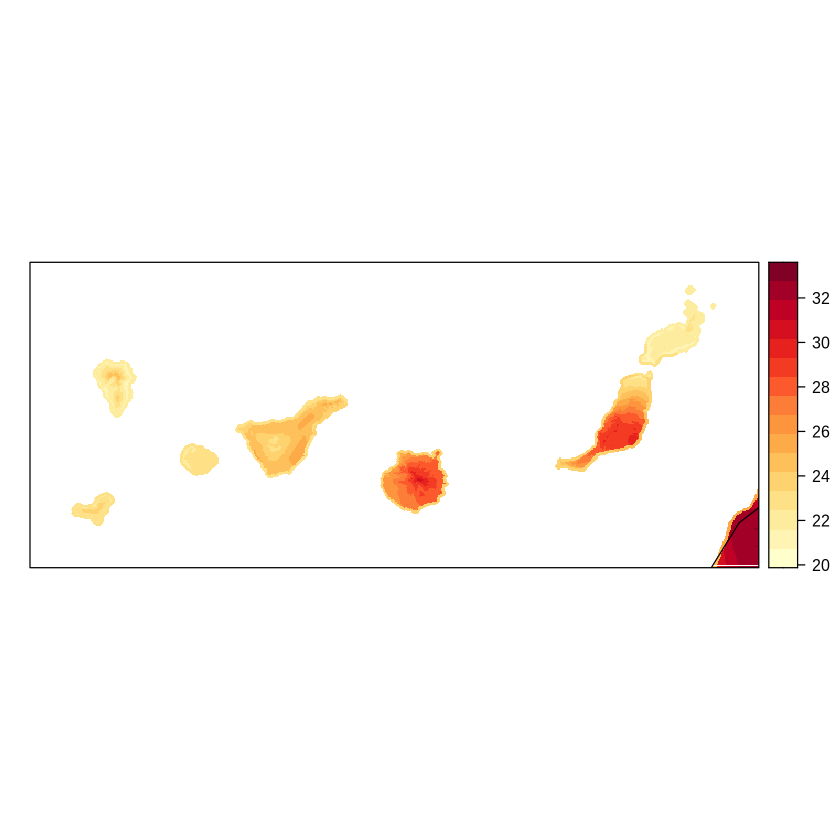

In [11]:
spatialPlot(climatology(tasmax.chelsa), color.theme="YlOrRd", backdrop.theme = "coastline")

[2025-05-12 12:05:18.079378] - Computing climatology...

[2025-05-12 12:05:18.240881] - Done.



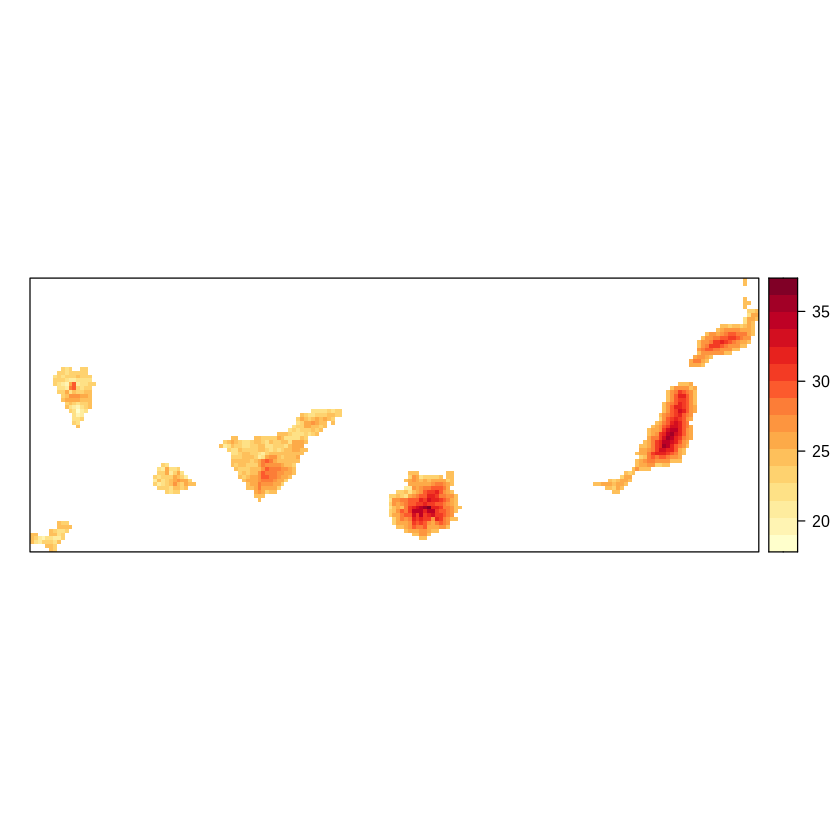

In [16]:
spatialPlot(climatology(tasmax.pti.v0), color.theme="YlOrRd", backdrop.theme = "coastline")

[2025-05-12 12:05:39.461519] - Computing climatology...

[2025-05-12 12:05:39.908772] - Done.



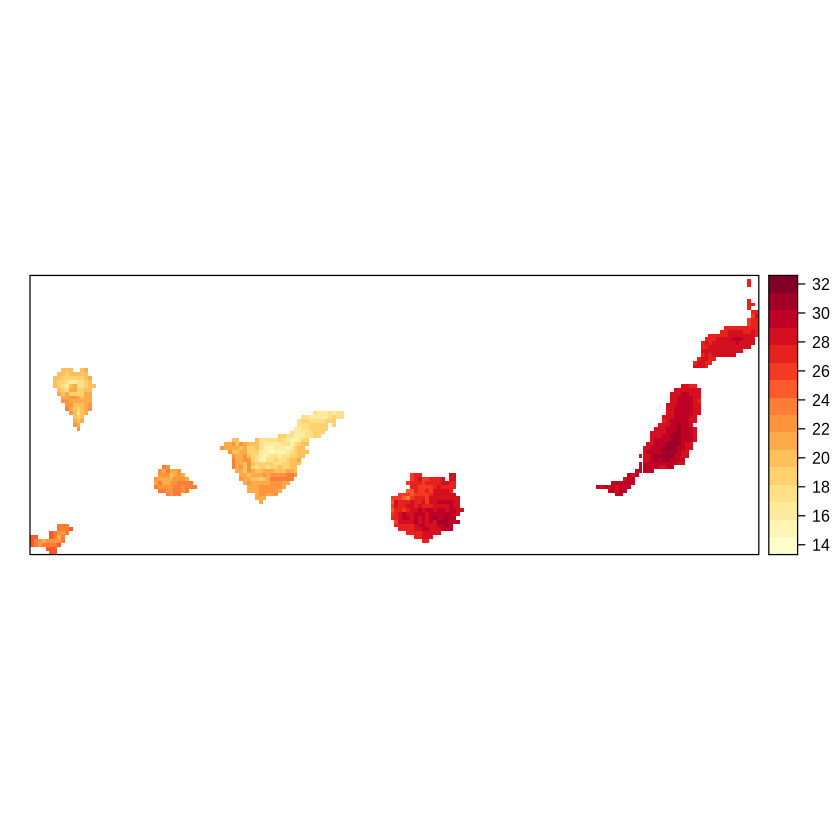

In [20]:
spatialPlot(climatology(tasmax.pti.v1), color.theme="YlOrRd", backdrop.theme = "coastline")

#### 4.2. Comparación de las medias climátologicas de los tres datasets

Una vez hemos visto como cargar cada uno de los datasets por separado, vamos a realizar una comparación entre los tres. El objetivo es observar la diferencia de resolución de lo tres y por otra parte comprobar si los resultados obtenidos para el perido de análisis escogido coinciden.

Guardamos los elementos de ***spatialPlot*** en variables, ya que como se verá a continuación, al tener diferentes valores de latitud/logintud no se pueden agrupar en un mismo gráfico. Cuándo se tengan guardados, llamamos a la función ***gridArrange*** y de esta manera representamos los tres datasets en una misma figura, facilitando la visualización y las posibles diferencias. Para observar diferencias, es necesario que todas las visualizaciones tengan la misma *colorbar*.

In [21]:
sp1 <- spatialPlot(climatology(tasmax.chelsa), color.theme="YlOrRd", backdrop.theme = "coastline", set.min = 10, set.max=40, at=seq(10,40,3), main = "Dataset Chelsa",
                   xlab="Longitude", ylab="Latitude", 
                   colorkey = list(space = "right",
                            title = list("º C", cex = 1)))
sp2 <- spatialPlot(climatology(tasmax.pti.v0), color.theme="YlOrRd", backdrop.theme = "coastline", set.min = 10, set.max=40, at=seq(10,40,3), main = "Dataset PTI-V0",
                   xlab="Longitude", ylab="Latitude", 
                   colorkey = list(space = "right",
                            title = list("º C", cex = 1)))
sp3 <- spatialPlot(climatology(tasmax.pti.v1),  color.theme="YlOrRd", backdrop.theme = "coastline", set.min = 10, set.max=40, at=seq(10,40,3), main = "Dataset PTI-V1",
                   xlab="Longitude", ylab="Latitude", 
                   colorkey = list(space = "right",
                            title = list("º C", cex = 1)))

[2025-05-12 12:05:46.024417] - Computing climatology...

[2025-05-12 12:05:47.890778] - Done.

[2025-05-12 12:05:48.48137] - Computing climatology...

[2025-05-12 12:05:48.624259] - Done.

[2025-05-12 12:05:48.686932] - Computing climatology...

[2025-05-12 12:05:48.823577] - Done.



Se modifican las opciones predeterminadas de salida, para ver las figuras más grandes y observar mejor las posibles diferencias.

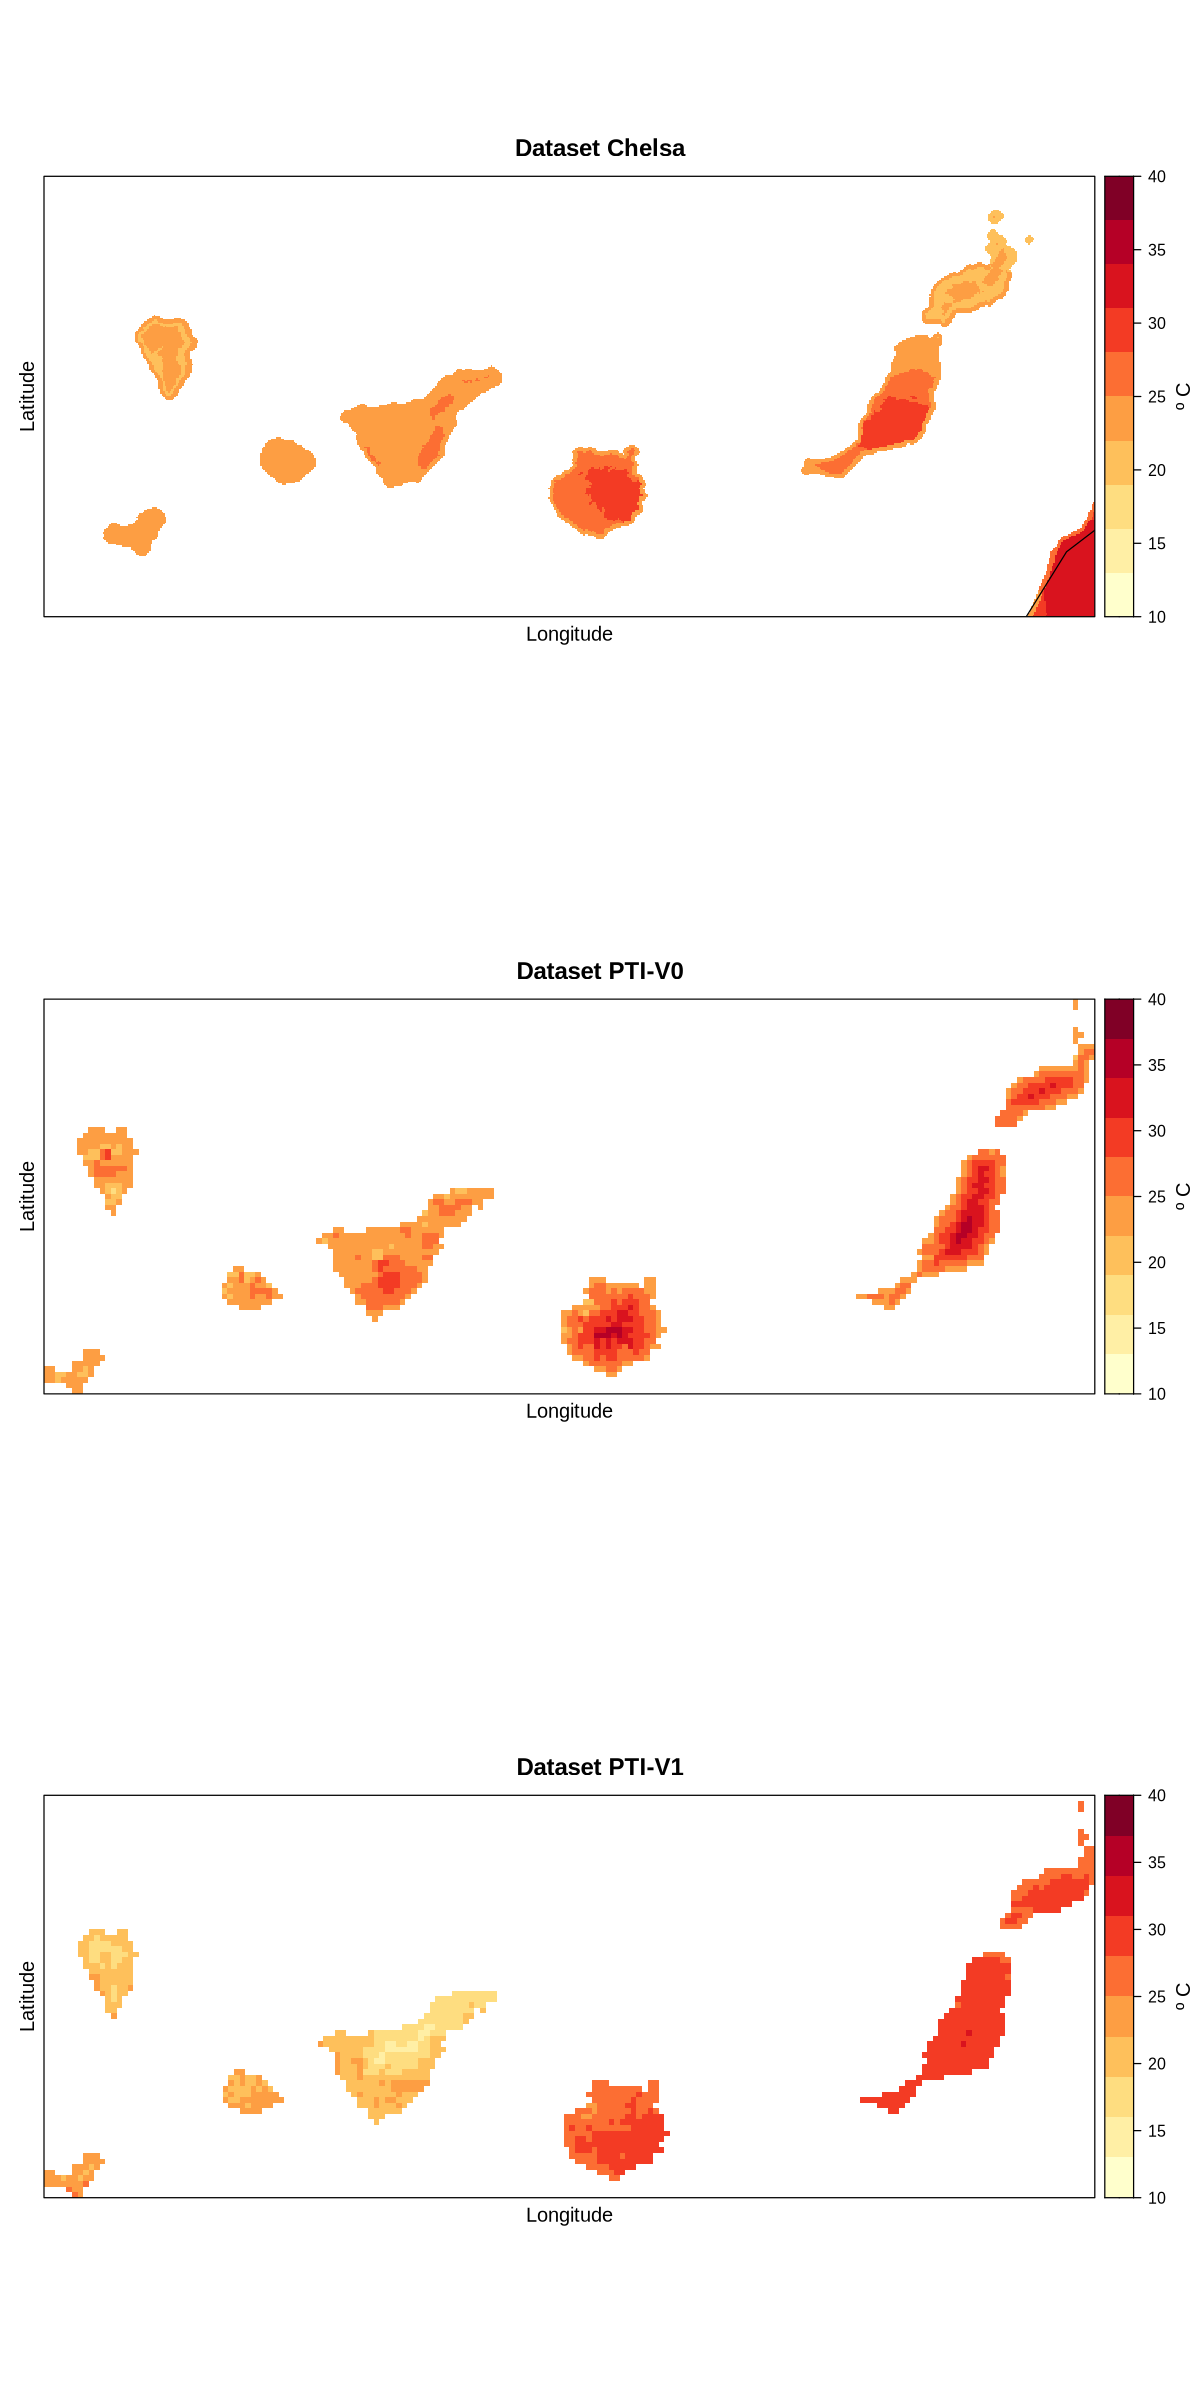

In [22]:
options(repr.plot.width = 10, repr.plot.height = 20)
grid.arrange(sp1, sp2, sp3)

#### 4.3. Series temporales


Otra opción de representación son las series temporales. Para su representación, tenemos que elegir gridboxes concretos. Al observar la representación espacial de la climatología de la Tmax, se puede observar que hay bastante diferencia entre los datasets, así que se van a estudiar las series temporales para dos gridboxes distintos, uno en la isla de Santa Cruz de Tenerife y otro en la isla de Fuerteventura.

In [29]:
# Definimos los valores de latitud y longitud de cada gridbox
# Santa Cruz de Tenerife
lat.sc <- 28.4
lon.sc <- -16.5
# Fuerteventura
lat.f <- 28.5
lon.f <- -13.9

Tenemos que obtener el subconjunto que corresponda al gridbox que queremos analizar de los tres datasets, usamos la función *subsetGrid*.

In [24]:
# Santa Cruz de Tenerife
tasmax.chelsa.sc <- subsetGrid(tasmax.chelsa, latLim=lat.sc, lonLim=lon.sc)
tasmax.pti.v0.sc <- subsetGrid(tasmax.pti.v0, latLim=lat.sc, lonLim=lon.sc)
tasmax.pti.v1.sc <- subsetGrid(tasmax.pti.v1, latLim=lat.sc, lonLim=lon.sc)
# Fuerteventura
tasmax.chelsa.f <- subsetGrid(tasmax.chelsa, latLim=lat.f, lonLim=lon.f)
tasmax.pti.v0.f <- subsetGrid(tasmax.pti.v0, latLim=lat.f, lonLim=lon.f)
tasmax.pti.v1.f <- subsetGrid(tasmax.pti.v1, latLim=lat.f, lonLim=lon.f)

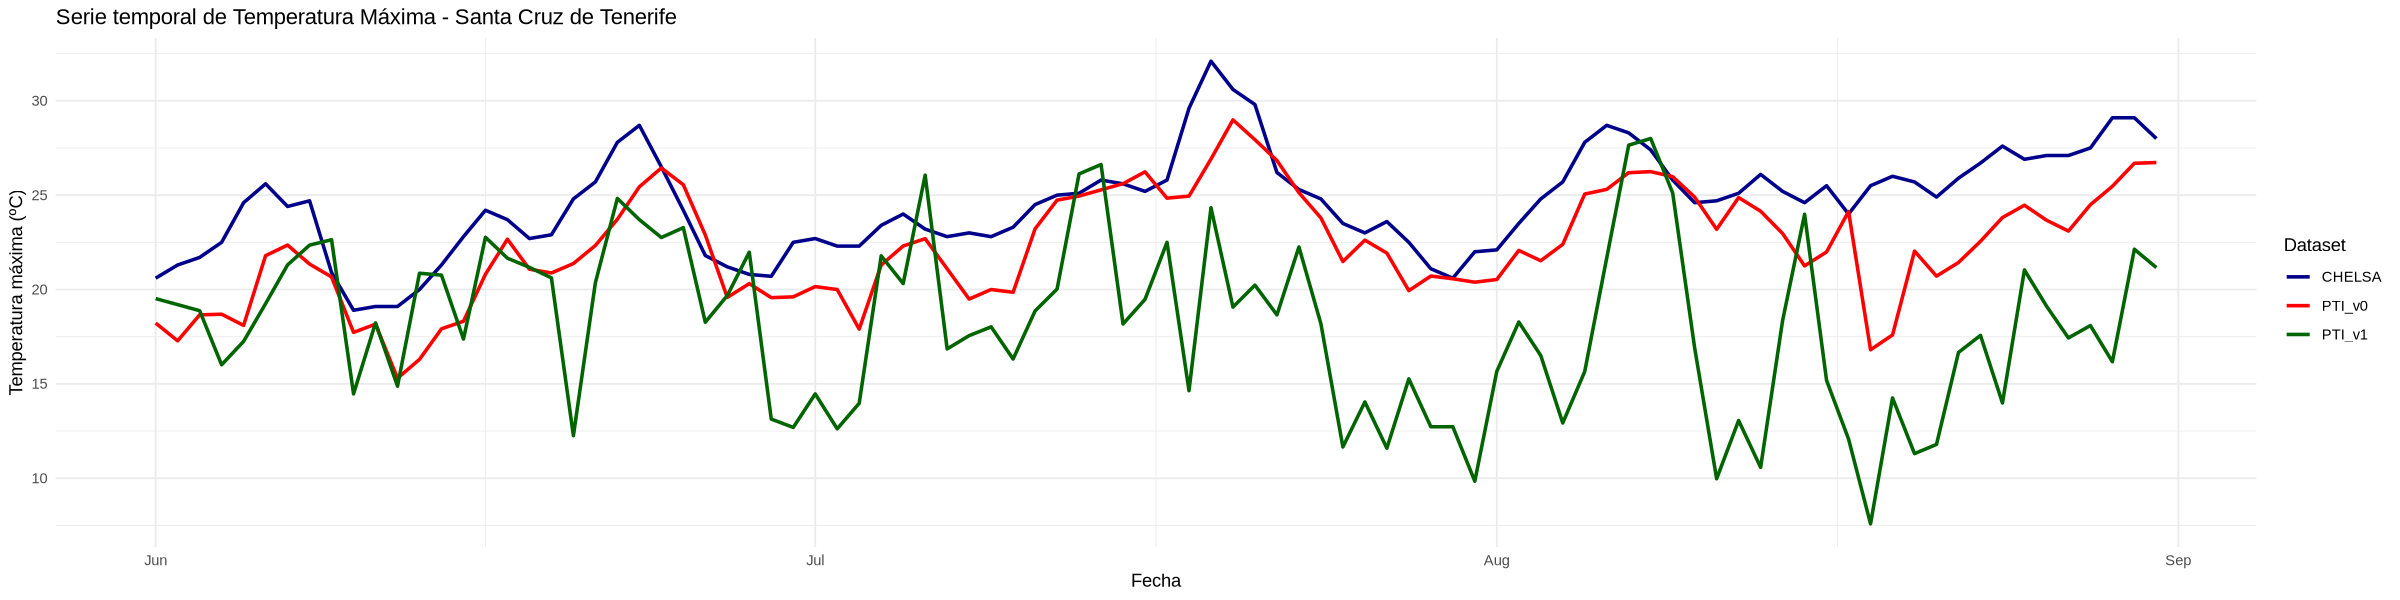

In [25]:
########### SANTA CRUZ DE TENERIFE
options(repr.plot.width = 20, repr.plot.height = 5)
# Extraemos las fechas y datos de cada dataset, creando dataframes
df_chelsa <- data.frame(
  date = as.Date(tasmax.chelsa.sc$Dates$start),
  tasmax = tasmax.chelsa.sc$Data,
  dataset = "CHELSA"
)

df_pti_v0 <- data.frame(
  date = as.Date(tasmax.pti.v0.sc$Dates$start),
  tasmax = tasmax.pti.v0.sc$Data,
  dataset = "PTI_v0"
)

df_pti_v1 <- data.frame(
  date = as.Date(tasmax.pti.v1.sc$Dates$start),
  tasmax = tasmax.pti.v1.sc$Data,
  dataset = "PTI_v1"
)

# Juntamos los tres datasets en uno
df_all <- rbind(df_chelsa, df_pti_v0, df_pti_v1)

# Creamos la visualización de la serie temporal
ggplot(df_all, aes(x = date, y = tasmax, color = dataset)) +
  geom_line(linewidth = 1) +
  labs(
    title = "Serie temporal de Temperatura Máxima - Santa Cruz de Tenerife",
    x = "Fecha",
    y = "Temperatura máxima (ºC)",
    color = "Dataset"
  ) +
  theme_minimal() +
  scale_color_manual(values = c("CHELSA" = "darkblue", "PTI_v0" = "red", "PTI_v1" = "darkgreen"))


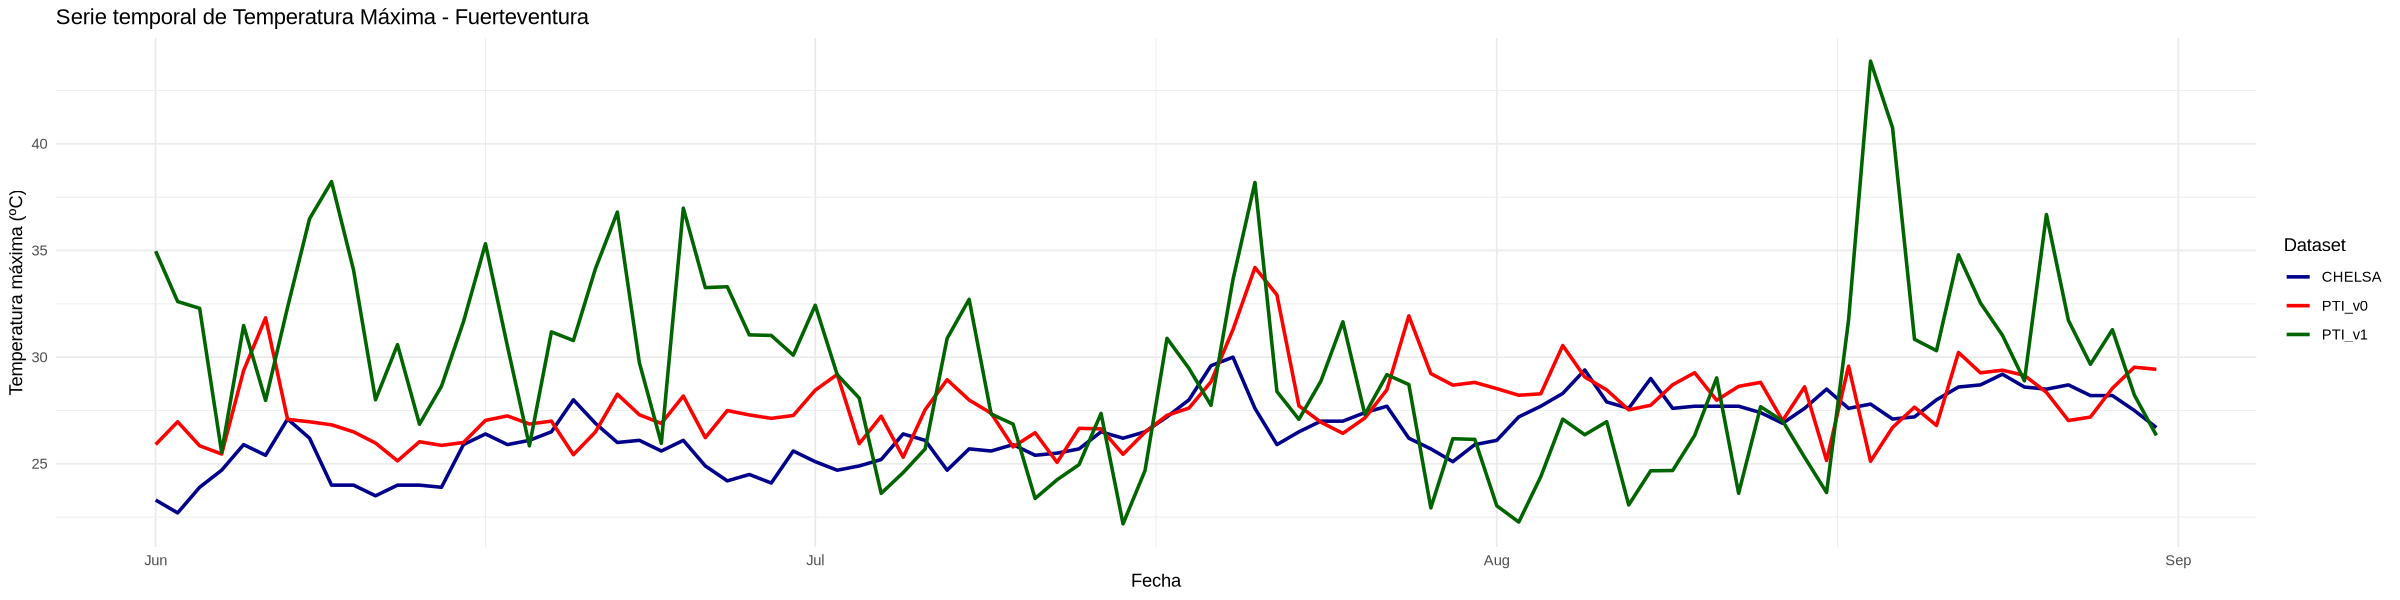

In [26]:
########### FUERTEVENTURA
options(repr.plot.width = 20, repr.plot.height = 5)
# Extraemos las fechas y datos de cada dataset, creando dataframes
df_chelsa <- data.frame(
  date = as.Date(tasmax.chelsa.f$Dates$start),
  tasmax = tasmax.chelsa.f$Data,
  dataset = "CHELSA"
)

df_pti_v0 <- data.frame(
  date = as.Date(tasmax.pti.v0.f$Dates$start),
  tasmax = tasmax.pti.v0.f$Data,
  dataset = "PTI_v0"
)

df_pti_v1 <- data.frame(
  date = as.Date(tasmax.pti.v1.f$Dates$start),
  tasmax = tasmax.pti.v1.f$Data,
  dataset = "PTI_v1"
)

# Juntamos los tres datasets en uno
df_all <- rbind(df_chelsa, df_pti_v0, df_pti_v1)

# Creamos la visualización de la serie temporal
ggplot(df_all, aes(x = date, y = tasmax, color = dataset)) +
  geom_line(linewidth = 1) +
  labs(
    title = "Serie temporal de Temperatura Máxima - Fuerteventura",
    x = "Fecha",
    y = "Temperatura máxima (ºC)",
    color = "Dataset"
  ) +
  theme_minimal() +
  scale_color_manual(values = c("CHELSA" = "darkblue", "PTI_v0" = "red", "PTI_v1" = "darkgreen"))

In [27]:
sessionInfo()

R version 4.3.3 (2024-02-29)
Platform: x86_64-conda-linux-gnu (64-bit)
Running under: Ubuntu 22.04.3 LTS

Matrix products: default
BLAS/LAPACK: /opt/conda/envs/climate4r/lib/libopenblasp-r0.3.28.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=en_US.UTF-8          LC_NUMERIC=C                 
 [3] LC_TIME=en_US.UTF-8           LC_COLLATE=en_US.UTF-8       
 [5] LC_MONETARY=en_US.UTF-8       LC_MESSAGES=en_US.UTF-8      
 [7] LC_PAPER=en_US.UTF-8          LC_NAME=en_US.UTF-8          
 [9] LC_ADDRESS=en_US.UTF-8        LC_TELEPHONE=en_US.UTF-8     
[11] LC_MEASUREMENT=en_US.UTF-8    LC_IDENTIFICATION=en_US.UTF-8

time zone: Etc/UTC
tzcode source: system (glibc)

attached base packages:
[1] grid      stats     graphics  grDevices utils     datasets  methods  
[8] base     

other attached packages:
[1] ggplot2_3.5.1       gridExtra_2.3       visualizeR_1.6.4   
[4] transformeR_2.2.2   loadeR_1.8.1        climate4R.UDG_0.2.6
[7] loadeR.java_1.1.1   rJava_1.0-11       

loaded via a name